# Synapsys — Quickstart

This notebook walks through the main features of the **synapsys** control systems library:

1. [Transfer Functions & State-Space Models](#1-transfer-functions--state-space-models)
2. [Block Diagram Algebra](#2-block-diagram-algebra)
3. [Frequency-Domain Analysis (Bode)](#3-frequency-domain-analysis)
4. [Continuous → Discrete Conversion](#4-continuous--discrete-conversion)
5. [PID Controller](#5-pid-controller)
6. [LQR (Linear Quadratic Regulator)](#6-lqr)
7. [Closed-Loop Simulation with Agents](#7-closed-loop-simulation-with-agents)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'lines.linewidth': 1.8,
})

## 1. Transfer Functions & State-Space Models

The API mirrors MATLAB: `tf()`, `ss()`, `step()`, `bode()`, `feedback()`.

In [2]:
# ── State-space: mesma planta G em outra representação ──────────────────
# G(s) = ωn²/(s²+2ζωns+ωn²)  em forma controlável canônica
# ẋ = Ax + Bu,  y = Cx + Du  com A=[[ 0, 1],[-ωn²,-2ζωn]], B=[[0],[1]], C=[[ωn²,0]], D=[[0]]
A_ss = np.array([[0.0, 1.0], [-wn**2, -2*zeta*wn]])
B_ss = np.array([[0.0], [1.0]])
C_ss = np.array([[wn**2, 0.0]])
D_ss = np.array([[0.0]])
G_ss = ss(A_ss, B_ss, C_ss, D_ss)

print(G_ss)
print(f"n_states : {G_ss.n_states}")
print(f"Poles    : {G_ss.poles()}")
print(f"Stable   : {G_ss.is_stable()}")


TransferFunction(num=[100.0], den=[1.0, 10.0, 100.0], continuous)
Poles    : [-5.+8.66025404j -5.-8.66025404j]
DC gain  : 1.0000+0.0000j
Stable   : True


In [3]:
# ── State-space: same plant from A, B, C, D ────────────────────────────────
# G(s) = 1/(s+1)  →  ẋ = -x + u,  y = x
G_ss = ss([[-1.0]], [[1.0]], [[1.0]], [[0.0]])

print(G_ss)
print(f"n_states : {G_ss.n_states}")
print(f"Poles    : {G_ss.poles()}")
print(f"Stable   : {G_ss.is_stable()}")

StateSpace(n_states=1, n_inputs=1, n_outputs=1, continuous)
n_states : 1
Poles    : [-1.+0.j]
Stable   : True


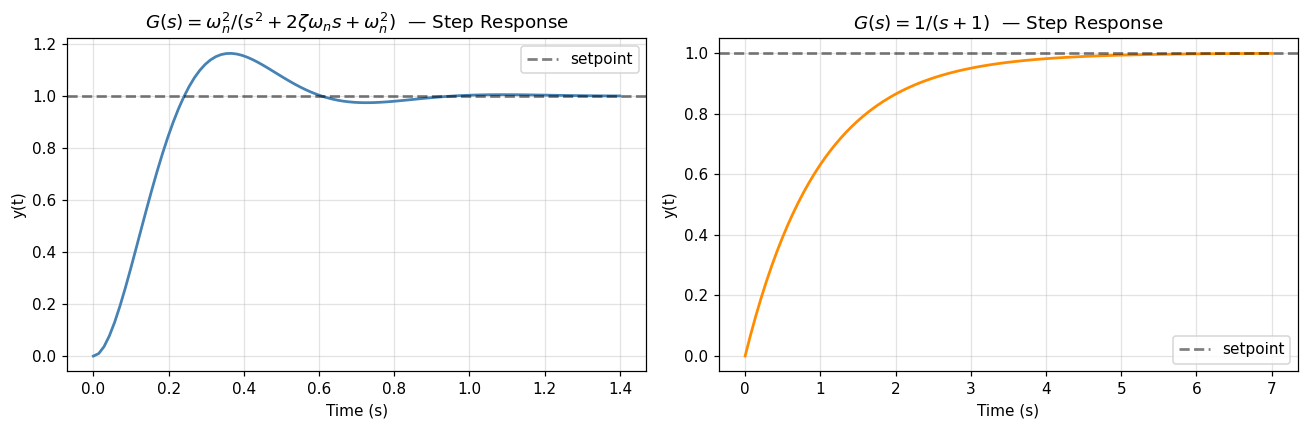

In [4]:
# ── Step response — tf() e ss() devem ser idênticos ────────────────────
t_G,  y_G  = step(G)
t_ss, y_ss = step(G_ss)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Esquerda: sobreposição — as curvas devem se coincidir
axes[0].plot(t_G,  y_G,  color="steelblue",  linewidth=2.5, label="tf() — TransferFunction")
axes[0].plot(t_ss, y_ss, color="darkorange", linewidth=1.2, linestyle="--", label="ss() — StateSpace")
axes[0].axhline(1.0, color="k", linestyle=":", alpha=0.45, label="setpoint")
axes[0].set_title(r"Same system — tf() vs ss()  ($\omega_n=10,\ \zeta=0.5$)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("y(t)")
axes[0].legend()

# Direita: erro absoluto entre as duas representações
import numpy as np as _np
# Interpola ss nos mesmos pontos de tf
y_ss_interp = np.interp(t_G, t_ss, y_ss)
err = np.abs(y_G - y_ss_interp)
axes[1].semilogy(t_G, err + 1e-16, color="crimson")
axes[1].set_title("Absolute error  |y_tf − y_ss|  (should be ≈ 0)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Error")

fig.tight_layout()
plt.show()


## 2. Block Diagram Algebra

Operators `*` (series), `+` (parallel), and `feedback()` work directly on system objects.

Open-loop poles  : [-1. -1.]
Closed-loop poles: [-1.+2.23606798j -1.-2.23606798j]
Closed-loop stable: True


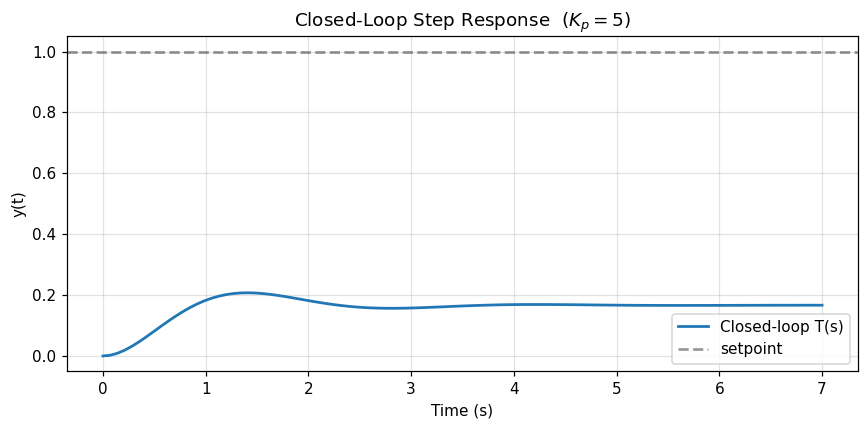

In [5]:
# Plant and proportional controller
P = tf([1], [1, 2, 1])          # G(s) = 1/(s+1)²
C = tf([5], [1])                 # C(s) = 5  (proportional gain)

open_loop = C * P                # L(s) = C·P
T = feedback(P, C)               # T(s) = P·C / (1 + P·C)

print(f"Open-loop poles  : {open_loop.poles()}")
print(f"Closed-loop poles: {T.poles()}")
print(f"Closed-loop stable: {T.is_stable()}")

# Step response — open vs closed loop
t_ol, y_ol = step(open_loop)
t_cl, y_cl = step(T)

plt.figure(figsize=(8, 4))
plt.plot(t_cl, y_cl, label='Closed-loop T(s)')
plt.axhline(1.0, color='k', linestyle='--', alpha=0.4, label='setpoint')
plt.title('Closed-Loop Step Response  ($K_p = 5$)')
plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Frequency-Domain Analysis

`bode()` returns `(ω, magnitude_dB, phase_deg)` — same convention as MATLAB.

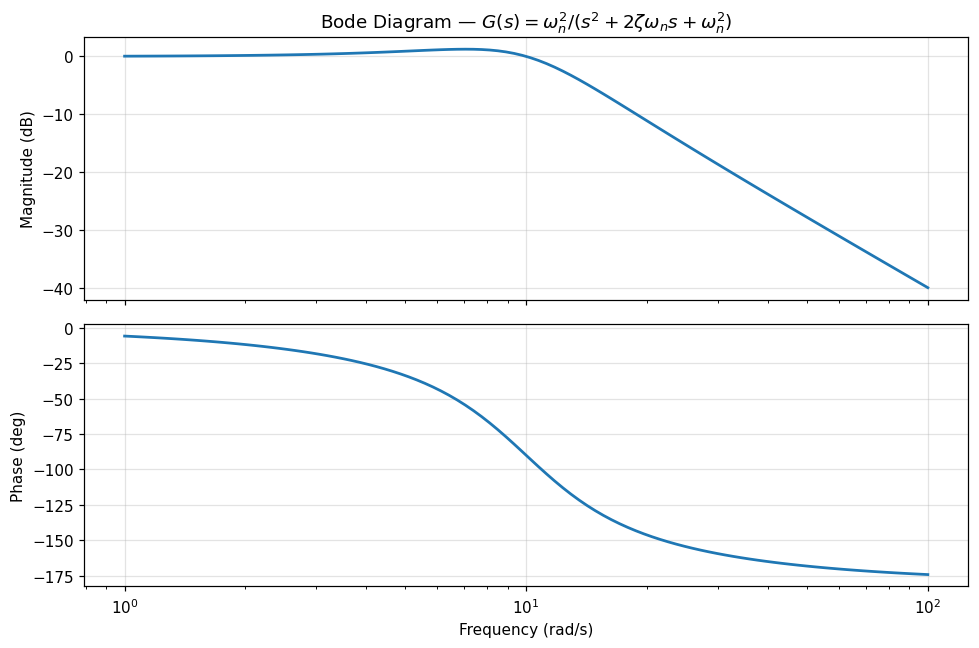

In [6]:
w, mag, phase = bode(G)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.semilogx(w, mag)
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title(r'Bode Diagram — $G(s) = \omega_n^2/(s^2+2\zeta\omega_n s+\omega_n^2)$')

ax2.semilogx(w, phase)
ax2.set_ylabel('Phase (deg)')
ax2.set_xlabel('Frequency (rad/s)')

fig.tight_layout()
plt.show()

## 4. Continuous → Discrete Conversion

`c2d()` supports `'zoh'`, `'bilinear'`, `'euler'`, and `'backward_diff'`.

/home/osfarias/workspace/workspace_mestrado/pycontrol/.venv/lib/python3.12/site-packages/scipy/signal/_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


ZOH discrete poles     : [0.70692192+0.32679053j 0.70692192-0.32679053j]
Bilinear discrete poles: [0.71428571+0.32991444j 0.71428571-0.32991444j]
ZOH stable: True


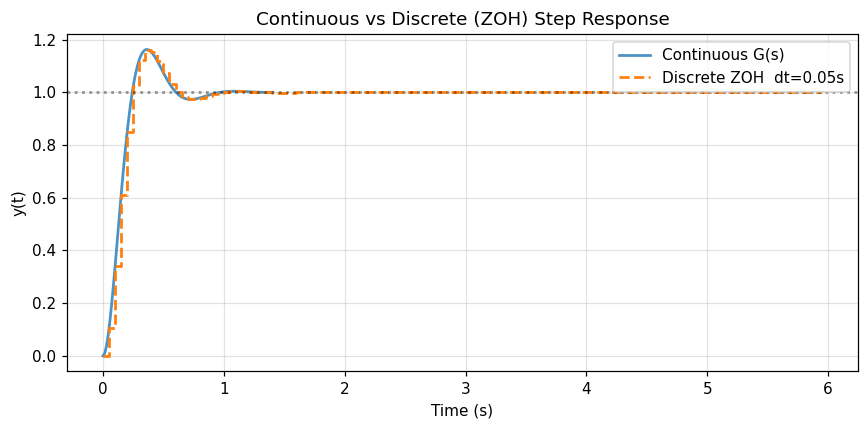

In [7]:
DT = 0.05  # 20 Hz

G_zoh      = c2d(G, dt=DT, method='zoh')
G_bilinear = c2d(G, dt=DT, method='bilinear')

print(f"ZOH discrete poles     : {G_zoh.poles()}")
print(f"Bilinear discrete poles: {G_bilinear.poles()}")
print(f"ZOH stable: {G_zoh.is_stable()}")

# Compare continuous vs discrete step response
t_c,   y_c   = step(G)
t_d,   y_d   = step(G_zoh, n=120)

plt.figure(figsize=(8, 4))
plt.plot(t_c, y_c, label='Continuous G(s)', alpha=0.8)
plt.step(t_d, y_d, where='post', label=f'Discrete ZOH  dt={DT}s', linestyle='--')
plt.axhline(1.0, color='k', linestyle=':', alpha=0.4)
plt.title('Continuous vs Discrete (ZOH) Step Response')
plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. PID Controller

Discrete PID with anti-windup and output saturation.  Simulate a closed-loop manually.

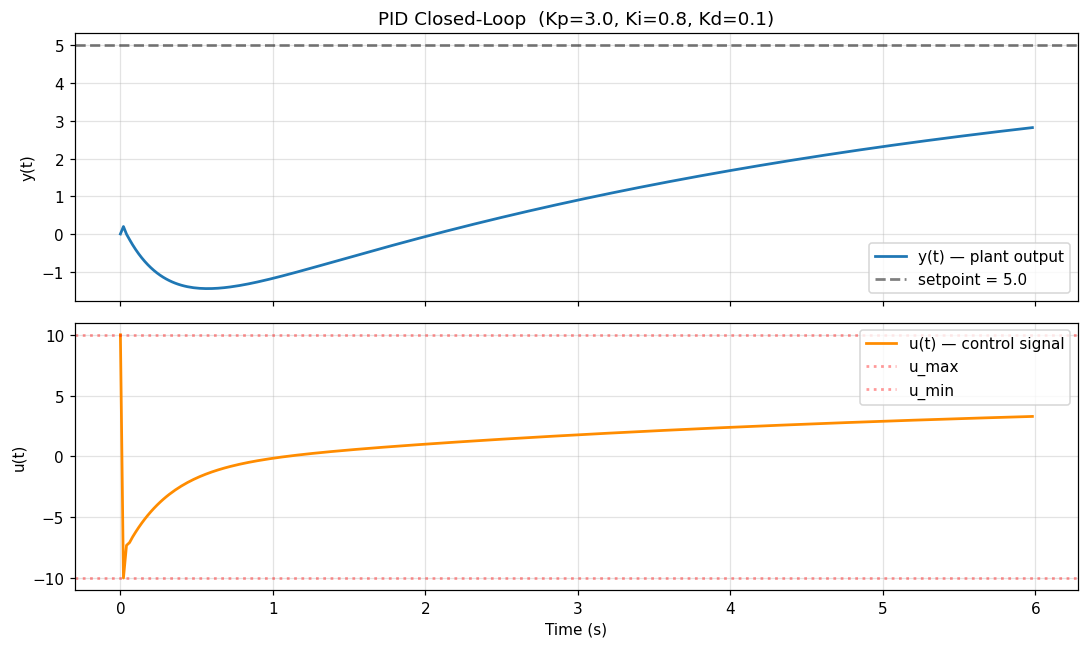

Final output    : 2.8195
Steady-state error: 2.180532


In [8]:
from synapsys.algorithms import PID

# Plant: G(s) = 1/(s+1)  discretised at 50 Hz
dt    = 0.02
plant = c2d(ss([[-1.0]], [[1.0]], [[1.0]], [[0.0]]), dt=dt)

pid = PID(Kp=3.0, Ki=0.8, Kd=0.1, dt=dt, u_min=-10.0, u_max=10.0)

setpoint = 5.0
N = 300

x   = np.array([[0.0]])   # plant state
ts, ys, us, es = [], [], [], []

for k in range(N):
    t_k = k * dt
    y   = float((plant.C @ x + plant.D * 0)[0, 0])
    u   = pid.compute(setpoint=setpoint, measurement=y)
    x, _ = plant.evolve(x, np.array([[u]]))
    x   = x.reshape(-1, 1)

    ts.append(t_k)
    ys.append(y)
    us.append(u)
    es.append(setpoint - y)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(ts, ys, label='y(t) — plant output')
ax1.axhline(setpoint, color='k', linestyle='--', alpha=0.5, label=f'setpoint = {setpoint}')
ax1.set_ylabel('y(t)')
ax1.set_title(f'PID Closed-Loop  (Kp={pid.Kp}, Ki={pid.Ki}, Kd={pid.Kd})')
ax1.legend()

ax2.plot(ts, us, color='darkorange', label='u(t) — control signal')
ax2.axhline(10.0,  color='r', linestyle=':', alpha=0.4, label='u_max')
ax2.axhline(-10.0, color='r', linestyle=':', alpha=0.4, label='u_min')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('u(t)')
ax2.legend()

fig.tight_layout()
plt.show()

print(f"Final output    : {ys[-1]:.4f}")
print(f"Steady-state error: {abs(setpoint - ys[-1]):.6f}")

## 6. LQR

LQR solves the Algebraic Riccati Equation to find the optimal state-feedback gain **K**  
minimising $J = \int_0^\infty (x^T Q x + u^T R u)\, dt$.

In [9]:
from synapsys.algorithms import lqr

# Double integrator: ẍ = u  →  state = [x, ẋ]
A = np.array([[0.0, 1.0],
              [0.0, 0.0]])
B = np.array([[0.0],
              [1.0]])

# Weight matrices
Q = np.diag([10.0, 1.0])   # penalise position more than velocity
R = np.array([[1.0]])

K, P = lqr(A, B, Q, R)
print(f"LQR gain K = {K}")
print(f"Riccati  P =\n{P}")

A_cl = A - B @ K
cl_poles = np.linalg.eigvals(A_cl)
print(f"Closed-loop poles: {cl_poles}")
print(f"All Re(p) < 0 (stable): {np.all(np.real(cl_poles) < 0)}")

LQR gain K = [[3.16227766 2.70639157]]
Riccati  P =
[[8.5583616  3.16227766]
 [3.16227766 2.70639157]]
Closed-loop poles: [-1.35319578+1.1537499j -1.35319578-1.1537499j]
All Re(p) < 0 (stable): True


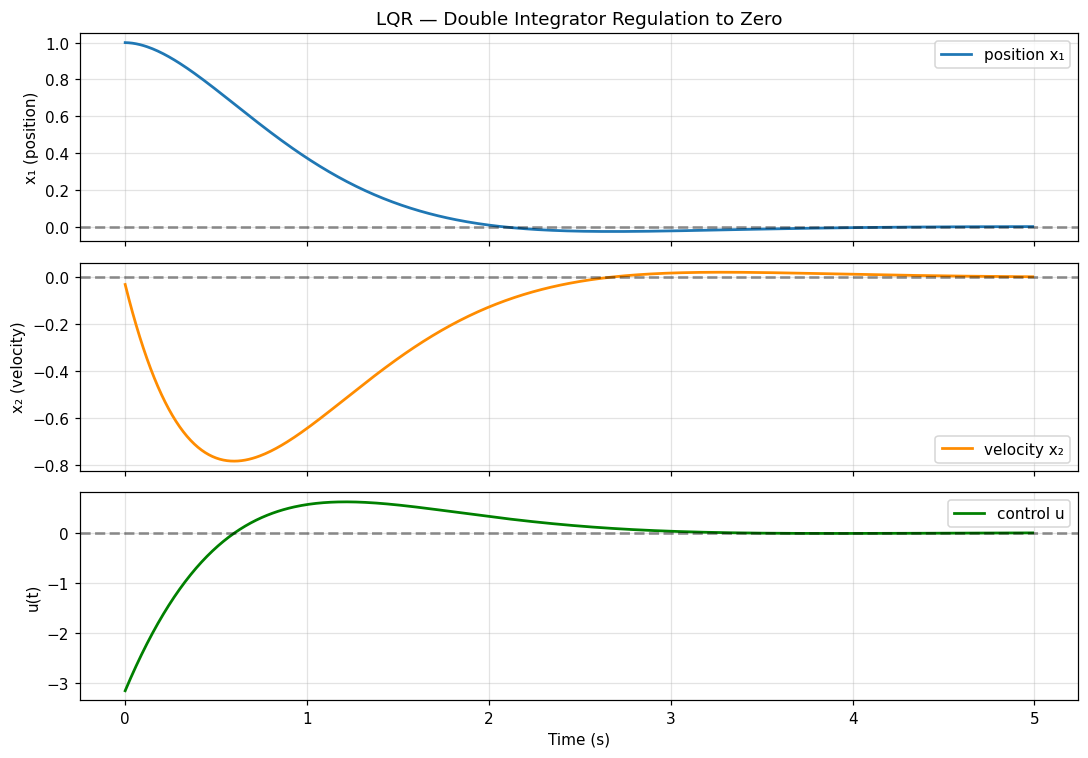

In [10]:
# Simulate LQR closed-loop (continuous, Euler integration)
dt_lqr = 0.01
T_lqr  = 5.0
steps  = int(T_lqr / dt_lqr)

x_lqr  = np.array([1.0, 0.0])   # initial condition: position=1, velocity=0
t_hist, x_hist, u_hist = [], [], []

for k in range(steps):
    u_lqr = -(K @ x_lqr).flatten()[0]
    x_lqr = x_lqr + dt_lqr * (A @ x_lqr + B.flatten() * u_lqr)
    t_hist.append(k * dt_lqr)
    x_hist.append(x_lqr.copy())
    u_hist.append(u_lqr)

t_arr = np.array(t_hist)
x_arr = np.array(x_hist)
u_arr = np.array(u_hist)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t_arr, x_arr[:, 0], label='position x₁')
axes[0].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[0].set_ylabel('x₁ (position)')
axes[0].set_title('LQR — Double Integrator Regulation to Zero')
axes[0].legend()

axes[1].plot(t_arr, x_arr[:, 1], color='darkorange', label='velocity x₂')
axes[1].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[1].set_ylabel('x₂ (velocity)')
axes[1].legend()

axes[2].plot(t_arr, u_arr, color='green', label='control u')
axes[2].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[2].set_ylabel('u(t)')
axes[2].set_xlabel('Time (s)')
axes[2].legend()

fig.tight_layout()
plt.show()

## 7. Closed-Loop Simulation with Agents

`PlantAgent` and `ControllerAgent` run in separate threads communicating via  
`SharedMemoryTransport` (zero-copy IPC). This mirrors real-world deployment where  
plant and controller are separate processes (or machines).

In [11]:
import time
from synapsys.agents import PlantAgent, ControllerAgent, SyncEngine, SyncMode
from synapsys.transport import SharedMemoryTransport

# ── 1. Discrete plant: G(s) = 1/(s+1) at 50 Hz ───────────────────────────
DT     = 0.02
plant  = c2d(ss([[-1.0]], [[1.0]], [[1.0]], [[0.0]]), dt=DT)

# ── 2. Shared memory bus ──────────────────────────────────────────────────
BUS      = "qs_demo"
CHANNELS = {"y": 1, "u": 1}

owner = SharedMemoryTransport(BUS, CHANNELS, create=True)
owner.write("y", np.array([0.0]))
owner.write("u", np.array([0.0]))

# ── 3. Separate handles (one per agent) ──────────────────────────────────
t_plant = SharedMemoryTransport(BUS, CHANNELS)
t_ctrl  = SharedMemoryTransport(BUS, CHANNELS)

# ── 4. PID law ────────────────────────────────────────────────────────────
SETPOINT = 3.0
pid_agent = PID(Kp=4.0, Ki=1.0, dt=DT, u_min=-15.0, u_max=15.0)
law = lambda y: np.array([pid_agent.compute(setpoint=SETPOINT, measurement=y[0])])

# ── 5. Create agents ──────────────────────────────────────────────────────
sync_plant = SyncEngine(SyncMode.WALL_CLOCK, dt=DT)
sync_ctrl  = SyncEngine(SyncMode.WALL_CLOCK, dt=DT)

plant_agent = PlantAgent("plant",      plant, t_plant, sync_plant)
ctrl_agent  = ControllerAgent("ctrl", law,   t_ctrl,  sync_ctrl)

# ── 6. Collect data from the owner handle ────────────────────────────────
SIM_TIME  = 3.0   # seconds
log_t, log_y, log_u = [], [], []

plant_agent.start(blocking=False)
ctrl_agent.start(blocking=False)

t0 = time.time()
while time.time() - t0 < SIM_TIME:
    log_t.append(time.time() - t0)
    log_y.append(owner.read("y")[0])
    log_u.append(owner.read("u")[0])
    time.sleep(DT)

plant_agent.stop()
ctrl_agent.stop()
t_plant.close()
t_ctrl.close()
owner.close()

print(f"Collected {len(log_t)} samples over {SIM_TIME}s")
print(f"Final y  : {log_y[-1]:.4f}  (setpoint = {SETPOINT})")

Collected 149 samples over 3.0s
Final y  : 2.7243  (setpoint = 3.0)


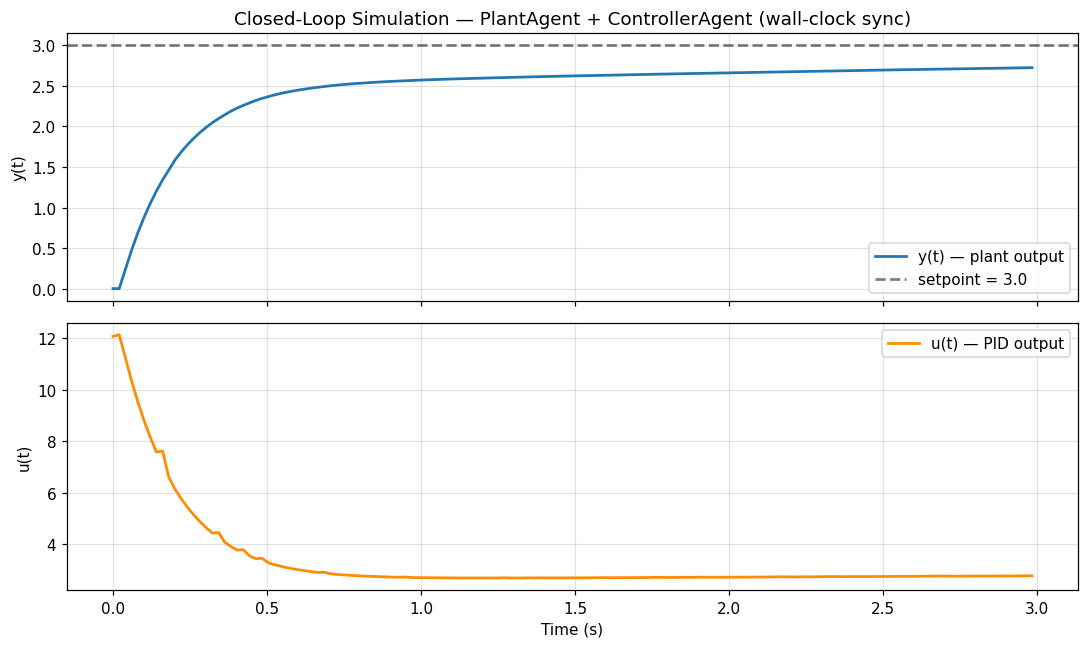

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(log_t, log_y, label='y(t) — plant output')
ax1.axhline(SETPOINT, color='k', linestyle='--', alpha=0.5, label=f'setpoint = {SETPOINT}')
ax1.set_ylabel('y(t)')
ax1.set_title('Closed-Loop Simulation — PlantAgent + ControllerAgent (wall-clock sync)')
ax1.legend()

ax2.plot(log_t, log_u, color='darkorange', label='u(t) — PID output')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('u(t)')
ax2.legend()

fig.tight_layout()
plt.show()

---

## Summary

| Feature | API |
|---------|-----|
| Transfer function | `tf(num, den)` |
| State-space model | `ss(A, B, C, D)` |
| Step response | `step(sys)` → `(t, y)` |
| Bode diagram | `bode(sys)` → `(ω, mag, phase)` |
| Feedback loop | `feedback(G, H=None)` |
| Discretise | `c2d(sys, dt, method)` |
| PID | `PID(Kp, Ki, Kd, dt, u_min, u_max)` |
| LQR | `lqr(A, B, Q, R)` → `(K, P)` |
| Distributed sim | `PlantAgent` + `ControllerAgent` + `SharedMemoryTransport` |

**Next steps:**
- 📖 [Full documentation](https://synapsys.github.io/synapsys/docs/)
- 🔧 [API Reference](https://synapsys.github.io/synapsys/docs/api/core)
- 🗺️ [Roadmap](https://synapsys.github.io/synapsys/docs/roadmap)